### Q-Learning:
- Q-Learning is a most popular reinforcement learning algorithm that helps an agent learn how to make the best predictions by interacting with its environment.
- Instead of needing a model of enivornment the agent learns purely from the experience by trying different actions and seeing the results.
### Key Components:
#### 1. Q-values or Action-Values:
- Q-values represent the expected rewards for taking an action in a specific state.
- These values are updated over time using the Termporal Office (TO) update rule.
#### 2. Rewards and Episodes:
- The agent moves through different states by taking actions and receving the rewards.
- This process continues until the agent reaches a terminal state which ends the episode.
#### 3. Temporal Difference (or) TD-Update:
- The agent updates Q-values using the formula:
  - Q(S, A) ← Q(S,A) + α(R + γQ(S̄,A̅) - Q(S,A))
- Where,
  - S is the current state.
  - A is the action taken by the agent.
  - S̄ is the next state the agent moves to.
  - A̅ is the best next action in state S̄.
  - γ(Gamma) is the discount factor which balances immediate rewards with future rewards.
  - α(Alpha) is the learning rate determing how much new information affects the old Q-values.
#### 4. ϵ-greedy Policy (Exploration vs. Exploitation):
- The ϵ-greedy policy helps the agent decide which action to take based on the current Q-values estimates.
  1. Exploitation - The agent picks the action with highest Q-value with probability 1-ϵ. This means the agent uses its current knowledge to maximize rewards.
  2. Exploration - With probabilitiy ϵ, the agent picks a random action, exploring new possibilities to learn if there are better ways to get rewards. This allows that agent to discover new strategies and improve its decision-making overtime.

### How does Q-Learning works?
#### 1. Start at a State(S):
- The enivornment provides the agent with a starting state which describes the current situation or condition.
#### 2. Agent Selects an Action(A):
- Based on the current state and the agent chooses an action using its policy.
- This decision is guided by a Q-table which estimates the potential rewards for different state-action pairs.
- The agent typically uses an ε-greedy strategy:
  1. It sometimes explores new actions(random choice).
  2. It mostly exploits known good actions( based on current Q-values).
#### 3. Action is Executed and Environment Responds:
- The agent performs the selected action. The environemnt then provides:
  1. A new state(S') - the result of the action.
  2. A reward(R) - feedback on the action's effectiveness.
#### 4. Learning Algorithm Updates the Q-Table:
- The agent updates the Q-Table using the new experiences:
  1. It adjusts the value for the state-action pair based on the received reward and the new state.
  2. This helps the agent better estimate which actions are more beneficial overtime.
#### 5. Policy is Refined and the Cycle Repeats:
- With updated Q-values the agent:
  1. Improves its policy to make better future decisions.
  2. Continues this loop - observing states, taking actions, receving rewards and updating Q-values across many episodes.

### Methods for Determing Q-values:
#### 1. Temporal distances:
- It is used to calculated by comparing the current state and action values with the previous ones.
- It provides a way to learn directly from experience, without needing a model of the environment.
#### 2. Bellman's Equation:
- It is a recursive formula used to calculate the value of a given state and determine the optimal action.
- It is a fundamental in the context of Q-learning and is expressed as:
  - Q(s,a) = R(s,a) + γ maxQ(s',a)
- where,
  - Q(s,a) - is the Q-value for a given state-action pair.
  - R(s,a) - is the immediate reward for taking action a in state s.
  - γ - is the discount factor, which represent a importance of future rewards.
  - maxQ(s',a) - is the maximum Q-valu for the next state s' and all possible actions.

### Implementation:
#### 1. Imported Libraries:
- We define the environment including the number of states, actions, goal state and the Q-table.
- Each state represents a position in a 4×4 grid and actions represent movements in four directions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n_states = 16
n_actions = 4
goal_state = 15

Q_table = np.zeros((n_states, n_actions))

#### 2. Set Hyperparameters:
- These parameters control the learning process:
  - learning_rate(α) - How much new info overrides old info.
  - discount_factor(γ) - How much future rewards are valued.
  - exploration_prob(ε) - Probability of taking a random action.
  - epochs - number of  trauning episodes.

In [2]:
learning_rate = 0.8
discount_factor = 0.95
exploration_prob = 0.2
epochs = 1000

#### 3. Define the State Transition Function:
- This function calculate the next state based on the current state and chosen action.
- We assume:
  - 0 →  Left.
  - 1 →  Right.
  - 2 →  Up.
  - 3 →  Down.

In [3]:
def get_next_state(state, action):
    row, col = divmod(state, 4)

    if action == 0 and col > 0:
        col -= 1
    elif action == 1 and col < 3:
        col += 1
    elif action == 2 and row > 0:
        row -= 1
    elif action == 3 and row < 3:
        row += 1

    return row * 4 + col

#### 4. Implement the Q-Learning Algorithm:
- Now we train the agent to learn optimal policy. At each step:
  1. Choose an action using epsilon-greedy policy.
  2. Move to the next state based on that action.
  3. Update the Q-value using the Bellman equation.
  4. End the episode if the goal is reached.
     

In [4]:
for epoch in range(epochs):
    current_state = np.random.randint(0, n_states)  

    while True:
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)
        else:
            action = np.argmax(Q_table[current_state])

        next_state = get_next_state(current_state, action)

        reward = 1 if next_state == goal_state else 0

        Q_table[current_state, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state]) - Q_table[current_state, action]
        )

        if next_state == goal_state:
            break

        current_state = next_state

#### 5. Output the Learned Q-Table:
- After training, we visualize the maximum Q-value of each state on a grid and print the Q-table.
- States closer to the goal should have higher Q-values, showing the agent's learned path.

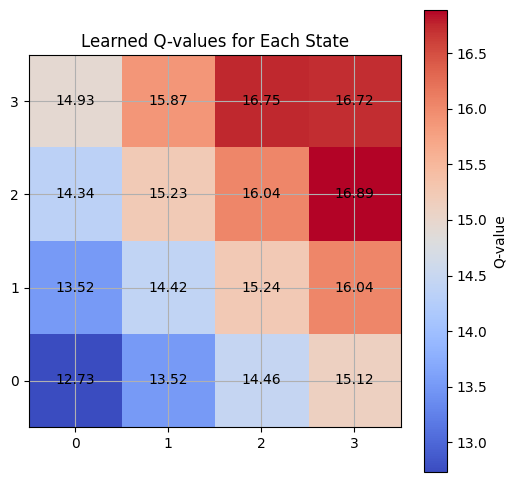

Learned Q-table:
[[ 9.58536417 11.82992318 11.6624793  12.73313692]
 [10.82259267  5.93022521 10.46276379 13.52137307]
 [12.10449562 11.46348768 13.33758916 14.45672268]
 [12.35270087  6.58692589 13.20595463 15.11725391]
 [11.9638611  12.93584915 10.29184759 13.52468935]
 [ 9.55476741 13.84921593 11.74936741 14.41724157]
 [12.44000213 15.23721015 13.50465201 15.04262406]
 [13.27414221 14.69211701 14.30144074 16.04274239]
 [12.43046839 14.34181238 12.50071709 11.79318985]
 [12.69241731 15.22682229 13.47897697 14.82477494]
 [14.35820438 16.04164627 14.10929347 15.53393143]
 [15.11282171 15.73784391 15.17156197 16.88734695]
 [11.98094579 14.92893817 12.47586485  9.57873506]
 [13.65223374 15.87128736 12.41089032 14.5459975 ]
 [14.61275529 16.75220443 14.70682955 13.83035769]
 [ 6.81007043 16.72352345 11.55312886 12.19075327]]


In [5]:
q_values_grid = np.max(Q_table, axis=1).reshape((4, 4))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for Each State')
plt.xticks(np.arange(4), ['0', '1', '2', '3'])
plt.yticks(np.arange(4), ['0', '1', '2', '3'])
plt.gca().invert_yaxis()
plt.grid(True)

for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

print("Learned Q-table:")
print(Q_table)